In [7]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.signal import savgol_filter

# 设置科研绘图风格
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

print("Libraries imported and style set.")

Libraries imported and style set.


In [8]:
# 读取数据
input_path = '../DataFormat/merged_cgm_data.csv'
print(f"Reading data from: {input_path}")

if os.path.exists(input_path):
    df = pd.read_csv(input_path)
    df['time'] = pd.to_datetime(df['time'])
    print(f"Data loaded successfully. Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Unique subjects: {df['id'].nunique()}")
else:
    print(f"Error: File not found at {input_path}")

Reading data from: ../DataFormat/merged_cgm_data.csv
Data loaded successfully. Shape: (101600, 5)
Columns: ['id', 'time', 'gl', 'age', 'bmi']
Unique subjects: 168


In [9]:
# 定义 S-G 滤波函数
def apply_sg_filter(data, window_length=15, polyorder=3):
    """
    应用 Savitzky-Golay 滤波器
    
    参数:
    data: 输入数据数组
    window_length: 窗口长度 (必须是奇数)。对于5分钟间隔的数据，15表示75分钟的窗口。
    polyorder: 多项式拟合阶数。3阶通常能较好地拟合生理信号。
    """
    if len(data) < window_length:
        return data # 数据太短无法滤波
    
    # mode='interp' 在边界处使用插值
    return savgol_filter(data, window_length, polyorder, mode='interp')

print("S-G Filter function defined.")

S-G Filter function defined.


In [10]:
# 应用 S-G 滤波
print("Applying Savitzky-Golay Filter to all subjects...")

# 参数设置
# 窗口长度 15 * 5min = 75min，能够平滑掉短期的噪声，同时保留餐后血糖峰值
WINDOW_LENGTH = 15 
POLYORDER = 3

filtered_dfs = []
unique_subjects = sorted(df['id'].unique())

for subject_id in unique_subjects:
    # 获取该受试者数据
    subject_data = df[df['id'] == subject_id].sort_values('time').copy()
    
    # 执行滤波
    gl_values = subject_data['gl'].values
    # 确保数据长度足够
    if len(gl_values) >= WINDOW_LENGTH:
        filtered_values = apply_sg_filter(gl_values, window_length=WINDOW_LENGTH, polyorder=POLYORDER)
    else:
        filtered_values = gl_values # 数据过短不处理
    
    # 保存结果
    subject_data['gl_sg'] = filtered_values
    
    # 计算残差 (Residuals)
    subject_data['residual'] = subject_data['gl'] - subject_data['gl_sg']
    
    filtered_dfs.append(subject_data)

# 合并结果
df_filtered = pd.concat(filtered_dfs, ignore_index=True)

print("Filtering complete.")
print(f"Filtered data shape: {df_filtered.shape}")
df_filtered.head()

Applying Savitzky-Golay Filter to all subjects...
Filtering complete.
Filtered data shape: (101600, 7)


,id,time,gl,age,bmi,gl_sg,residual
0,2,2012-01-01 00:00:00,167.0,42.0,30.0,169.746732,-2.746732
1,2,2012-01-01 00:05:00,163.0,42.0,30.0,162.297852,0.702148
2,2,2012-01-01 00:10:00,158.0,42.0,30.0,155.290688,2.709312
3,2,2012-01-01 00:15:00,151.0,42.0,30.0,148.809452,2.190548
4,2,2012-01-01 00:20:00,144.0,42.0,30.0,142.938357,1.061643


Generating plots for 10 subjects


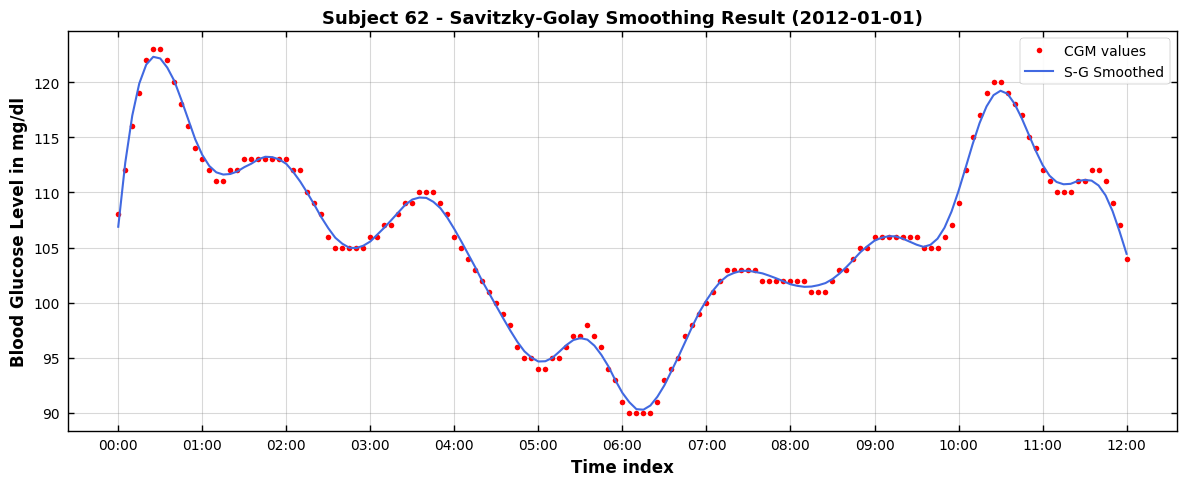

Visualization for Subject 62 generated.


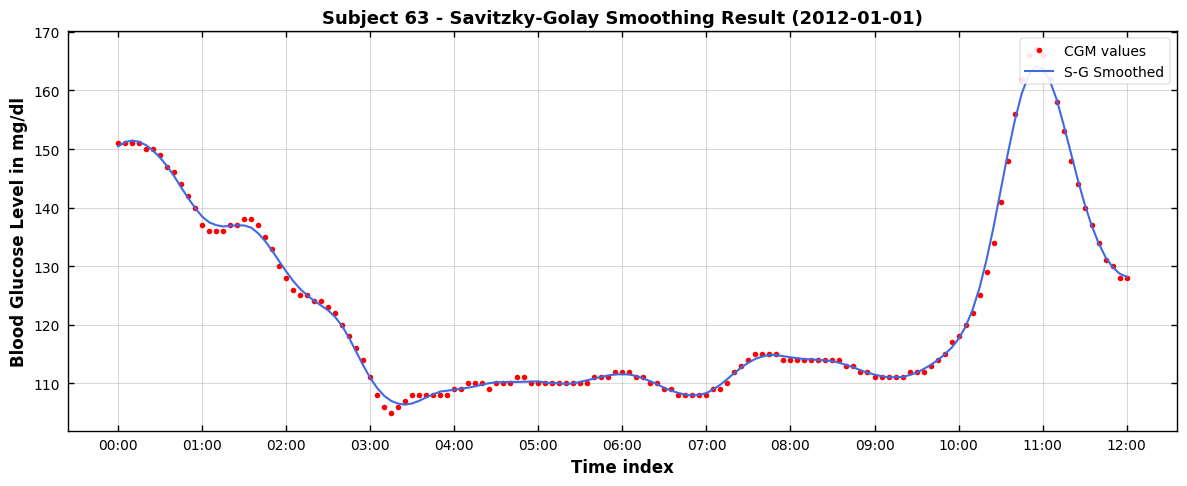

Visualization for Subject 63 generated.


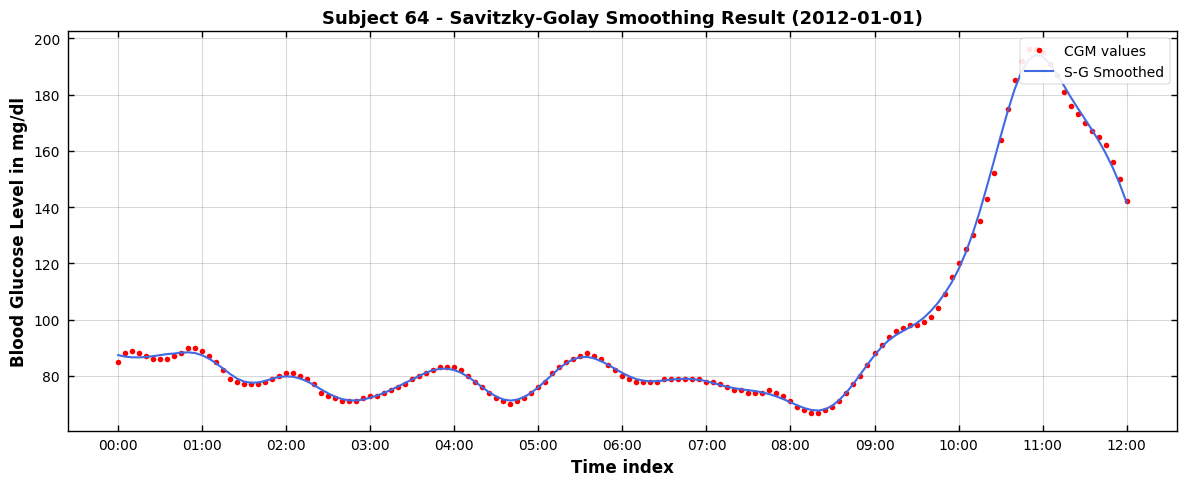

Visualization for Subject 64 generated.


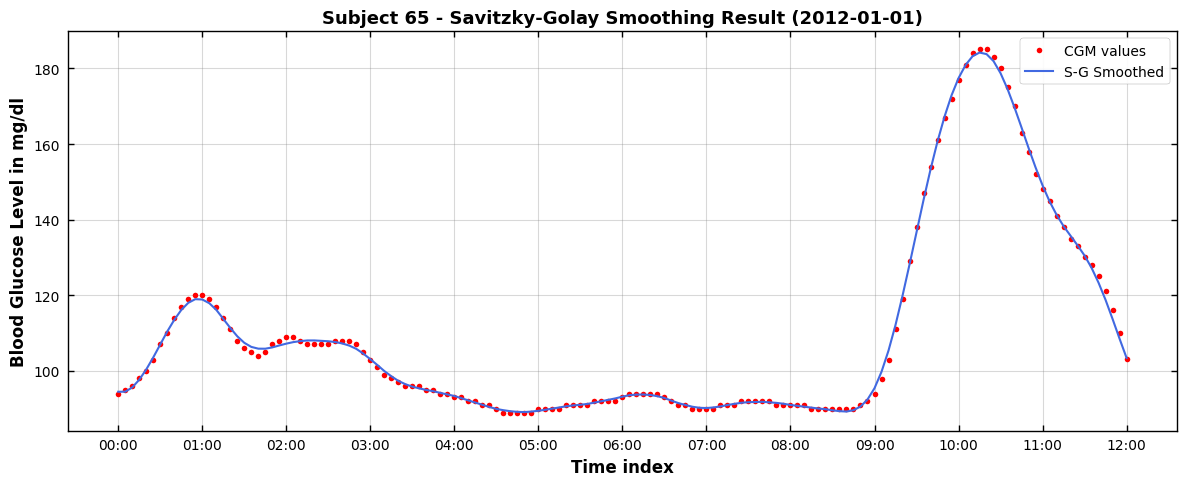

Visualization for Subject 65 generated.


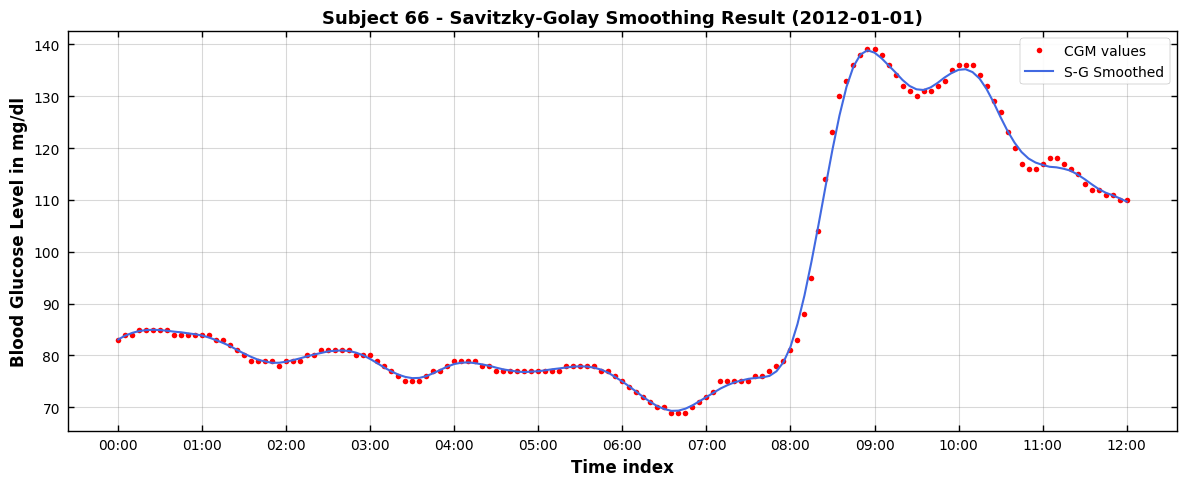

Visualization for Subject 66 generated.


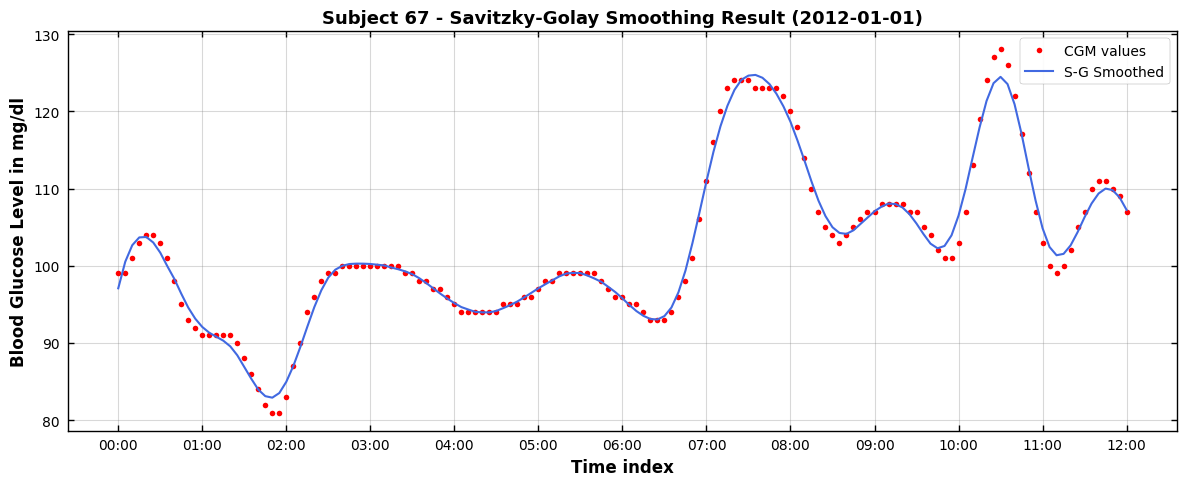

Visualization for Subject 67 generated.


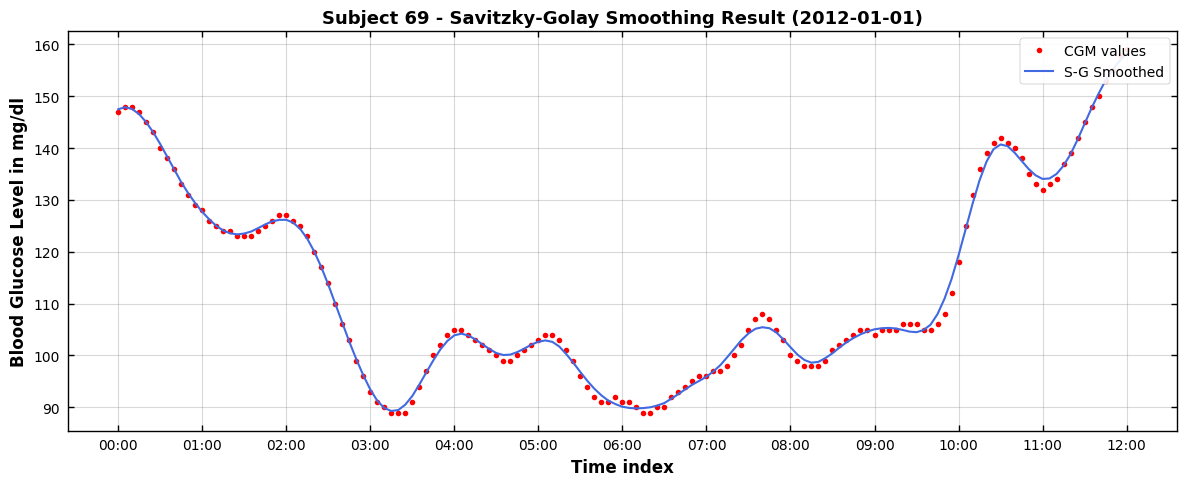

Visualization for Subject 69 generated.


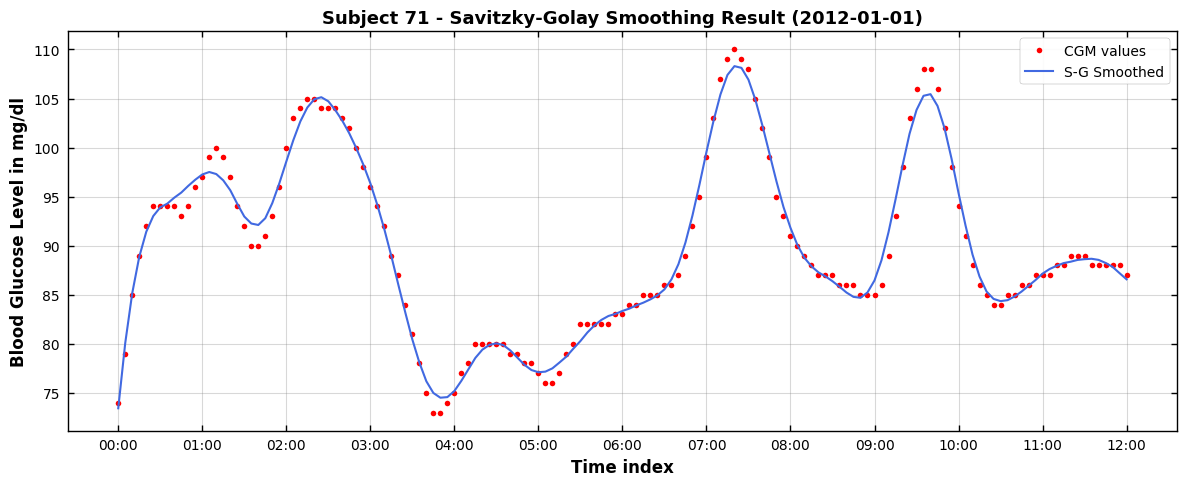

Visualization for Subject 71 generated.


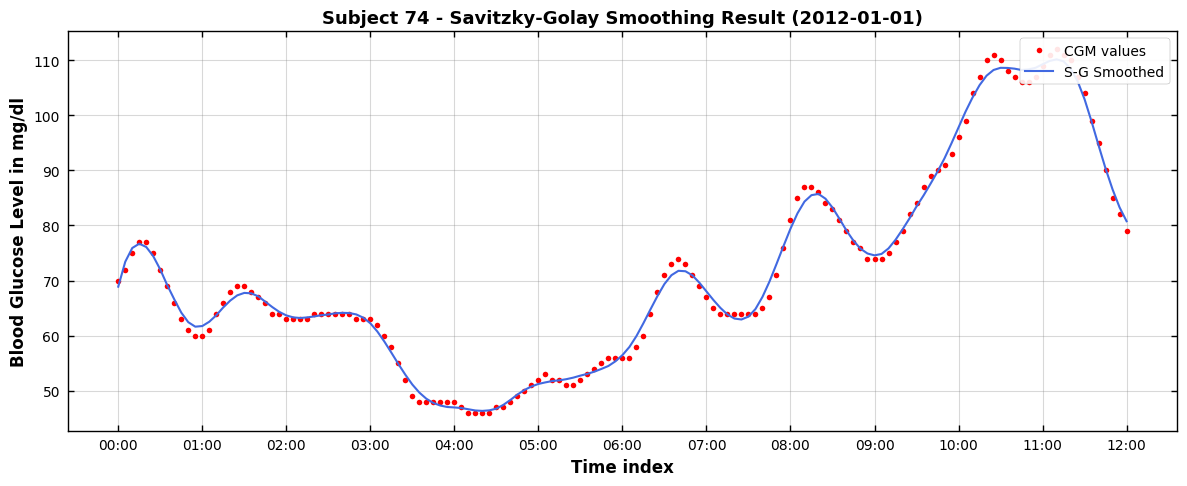

Visualization for Subject 74 generated.


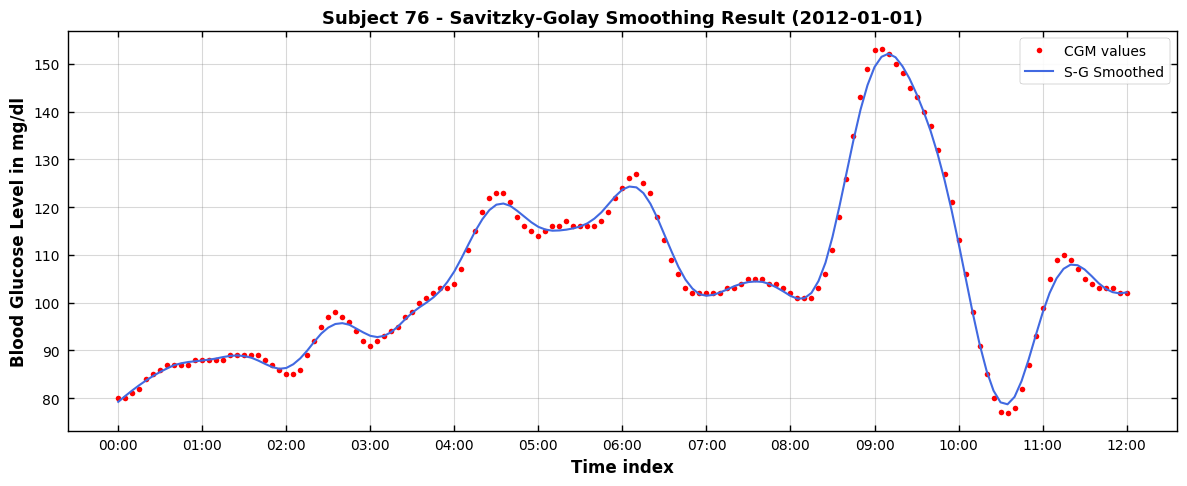

Visualization for Subject 76 generated.


In [11]:
# 可视化对比 (仿照参考图风格)
# 选择前3个受试者进行展示
subjects_to_plot = unique_subjects[50:60]

print(f"Generating plots for {len(subjects_to_plot)} subjects")

for i, subject_id in enumerate(subjects_to_plot):
    subject_data = df_filtered[df_filtered['id'] == subject_id].copy()
    
    # 找到数据点最多的一天
    subject_data['date'] = subject_data['time'].dt.date
    if subject_data.empty:
        continue
        
    best_date = subject_data['date'].value_counts().idxmax()
    full_day_data = subject_data[subject_data['date'] == best_date].sort_values('time')
    
    # 截取12小时的数据进行展示
    if not full_day_data.empty:
        start_time = full_day_data['time'].iloc[0]
        end_time = start_time + pd.Timedelta(hours=12)
        plot_data = full_day_data[(full_day_data['time'] >= start_time) & (full_day_data['time'] <= end_time)]
    else:
        plot_data = full_day_data

    if plot_data.empty:
        continue
    
    # 创建图表 - 单个图 (仿照论文风格)
    plt.figure(figsize=(12, 5))
    
    # 绘制原始数据 (红点)
    plt.plot(plot_data['time'], plot_data['gl'], '.', color='red', markersize=8, label='CGM values')
    
    # 绘制滤波数据 (蓝线)
    plt.plot(plot_data['time'], plot_data['gl_sg'], '-', color='royalblue', linewidth=1.5, label='S-G Smoothed')
    
    # 设置标签和标题
    plt.ylabel('Blood Glucose Level in mg/dl', fontweight='bold')
    plt.xlabel('Time index', fontweight='bold')
    plt.title(f'Subject {subject_id} - Savitzky-Golay Smoothing Result ({best_date})', fontweight='bold')
    
    # 设置图例 (右上角，带边框)
    plt.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='gray')
    
    # 设置网格 (向内刻度)
    plt.grid(True, alpha=0.3, linestyle='-', color='gray')
    
    # 格式化时间轴
    import matplotlib.dates as mdates
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) # 仅显示小时:分钟
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    
    # 设置边框和刻度样式
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color('black')
        
    plt.tick_params(direction='in', length=4, width=1, colors='black', top=True, right=True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Visualization for Subject {subject_id} generated.")

In [12]:
# 导出滤波后的数据
output_file = 'sg_filtered_cgm_data.csv'
print(f"Exporting filtered data to: {output_file}")

# 选择要导出的列
export_cols = ['id', 'time', 'gl_sg', 'age', 'bmi']
df_export = df_filtered[export_cols]

# 导出
df_export.to_csv(output_file, index=False)

print("Export complete.")
print(f"File saved: {os.path.abspath(output_file)}")
df_export.head()

Exporting filtered data to: sg_filtered_cgm_data.csv
Export complete.
File saved: c:\Users\江一骏\Desktop\学习\HKU\dissertation\engineering\code\GlucosePrediction\src\DataFillter\sg_filtered_cgm_data.csv


,id,time,gl_sg,age,bmi
0,2,2012-01-01 00:00:00,169.746732,42.0,30.0
1,2,2012-01-01 00:05:00,162.297852,42.0,30.0
2,2,2012-01-01 00:10:00,155.290688,42.0,30.0
3,2,2012-01-01 00:15:00,148.809452,42.0,30.0
4,2,2012-01-01 00:20:00,142.938357,42.0,30.0


## 总结

1.  **S-G 滤波**: 成功应用 Savitzky-Golay 滤波器 (Window=15, Poly=3)。
2.  **效果**: 相比于其他方法，S-G 滤波在平滑噪声的同时，较好地保留了血糖波动的峰值特征。
3.  **数据导出**: 结果已保存至 `sg_filtered_cgm_data.csv`。